In [1]:
import pathlib
from argparse import ArgumentParser
import yaml
import torch
# import src.spatial_attn_lightning as attn_tracking_lightning
from src.spatial_attn_lightning import BinauralAttentionModule 


%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [51]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def plot_attn_modules(attn_modules, figsize=(8,8), title=None):
    n_attn_blocks = len(attn_modules)  
    if n_attn_blocks == 1:
        fig, axs = plt.subplots(1, figsize=figsize)
        axs = [axs]
    else: 
        fig, axs = plt.subplots(n_attn_blocks//2, 2, sharex=True, figsize=figsize)
        axs = axs.ravel()
    x = np.linspace(-5,6, 100)
    
    layer_names = ['Cochleagram' if ix == 0 else f"Layer {ix}" for ix in range(n_attn_blocks)]

    for i, module in enumerate(attn_modules):
        bias = module.bias.item()
        slope = module.slope.item()
        threshold = module.threshold.item() 

        axs[i].plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope))
        axs[i].text(1.25, 0., f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
        axs[i].set_title(layer_names[i] if title is None else title)
        # axs[i].set_ylim(-0.1,1.1)
        axs[i].set_ylim(-0.1,1.1)
    return fig, axs

## Plot best feature-gain model

Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Using singe gain function per layer
Conv block order: LN -> Conv -> ReLU
fc_attn: True
coch_affine: True
Compiling model...
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


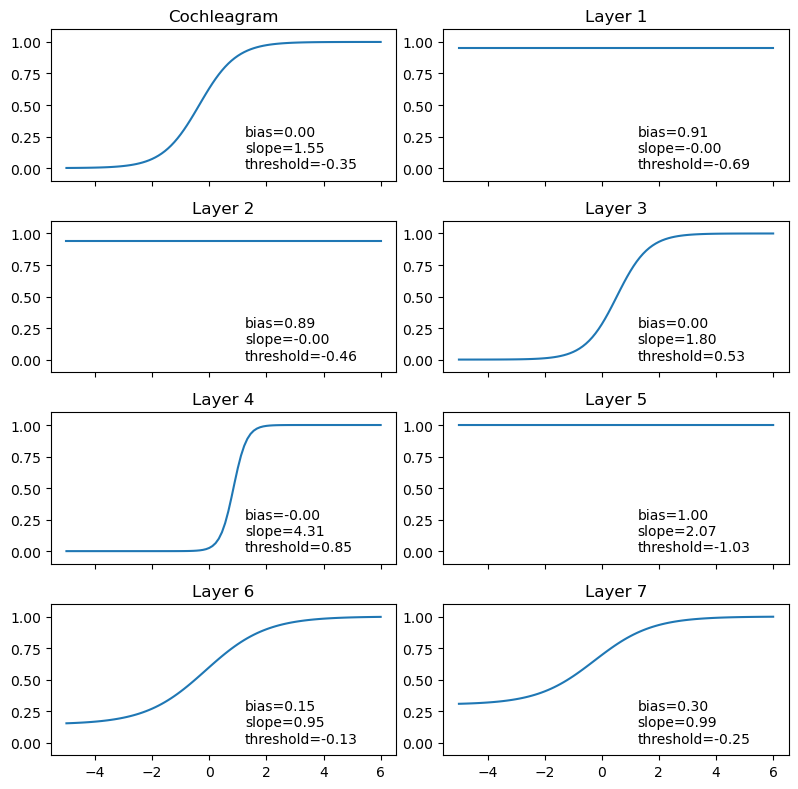

In [48]:
### Get most recent config
config_path = "config/binaural_attn/word_task_v10_main_feature_gain_config.yaml"
ckpt_path = "attn_cue_models/word_task_v10_main_feature_gain_config/checkpoints/epoch=3-step=48037.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))

model = BinauralAttentionModule(config=config)

model.load_state_dict(ckpt['state_dict'])
attn_modules = model.attn_modules

n_attn_blocks = len(attn_modules)   

fig, axs = plot_attn_modules(attn_modules)
plt.tight_layout()

## Plot early-only model

Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Using singe gain function per layer
Conv block order: LN -> Conv -> ReLU
fc_attn: False
coch_affine: True
Compiling model...


/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


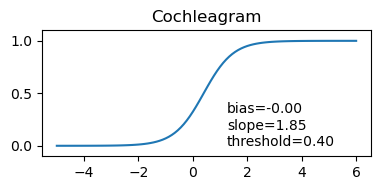

In [52]:
### Get most recent config
config_path = "config/binaural_attn/word_task_early_only_v10.yaml"
ckpt_path = "attn_cue_models/word_task_early_only_v10/checkpoints/epoch=7-step=92753.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))

model = BinauralAttentionModule(config=config)

model.load_state_dict(ckpt['state_dict'])
attn_modules = model.attn_modules

plot_attn_modules(attn_modules, figsize=(4,2))
plt.tight_layout()

## Plot Late-only 

Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Using singe gain function per layer
Conv block order: LN -> Conv -> ReLU
fc_attn: True
coch_affine: True
Compiling model...
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


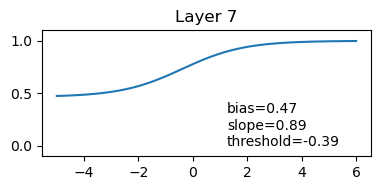

In [53]:
### Get most recent config
config_path = "config/binaural_attn/word_task_late_only_v10.yaml"
ckpt_path = "attn_cue_models/word_task_late_only_v10/checkpoints/epoch=7-step=96753.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))

model = BinauralAttentionModule(config=config)

model.load_state_dict(ckpt['state_dict'])
attn_modules = model.attn_modules

plot_attn_modules(attn_modules, figsize=(4,2), title='Layer 7')
plt.tight_layout()